In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.22.0-rc0
GPU available: []


In [2]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Configuration:")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)


Configuration:
Image size: (224, 224)
Batch size: 32
Maximum epochs: 10


In [3]:
possible_paths = [
    Path("data/cnn_train"),
    Path("../data/cnn_train"),
]

TRAIN_DIR = None

for path in possible_paths:
    if path.is_dir():
        TRAIN_DIR = path.resolve()
        break

if TRAIN_DIR is None:
    raise FileNotFoundError(
        "Road-damage dataset not found. "
        "Please place the dataset in data/cnn_train/ with one folder per class."
    )

print("Training directory:", TRAIN_DIR)
print("Exists:", TRAIN_DIR.is_dir())


Training directory: C:\Users\dhana\Desktop\Deep-Learning-Assignment\SE4050-Deep-Learning-Assignment\data\cnn_train
Exists: True


In [4]:
print("Road Damage Dataset Structure")
print("=" * 60)

class_dirs = [p for p in sorted(TRAIN_DIR.iterdir()) if p.is_dir()]

if len(class_dirs) < 2:
    raise ValueError(
        "At least 2 class folders are required for classification."
    )

for folder in class_dirs:
    image_count = sum(
        1 for f in folder.rglob("*")
        if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    )
    print(f"[CLASS] {folder.name}: {image_count} images")


Road Damage Dataset Structure
[CLASS] Czech: 2829 images
[CLASS] India: 7706 images
[CLASS] Japan: 2606 images


In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("\nRoad Damage Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)


Found 13141 files belonging to 3 classes.
Using 10513 files for training.
Found 13141 files belonging to 3 classes.
Using 2628 files for validation.

Road Damage Classes: ['Czech', 'India', 'Japan']
Number of classes: 3


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

print("Dataset pipeline ready.")


Dataset pipeline ready.


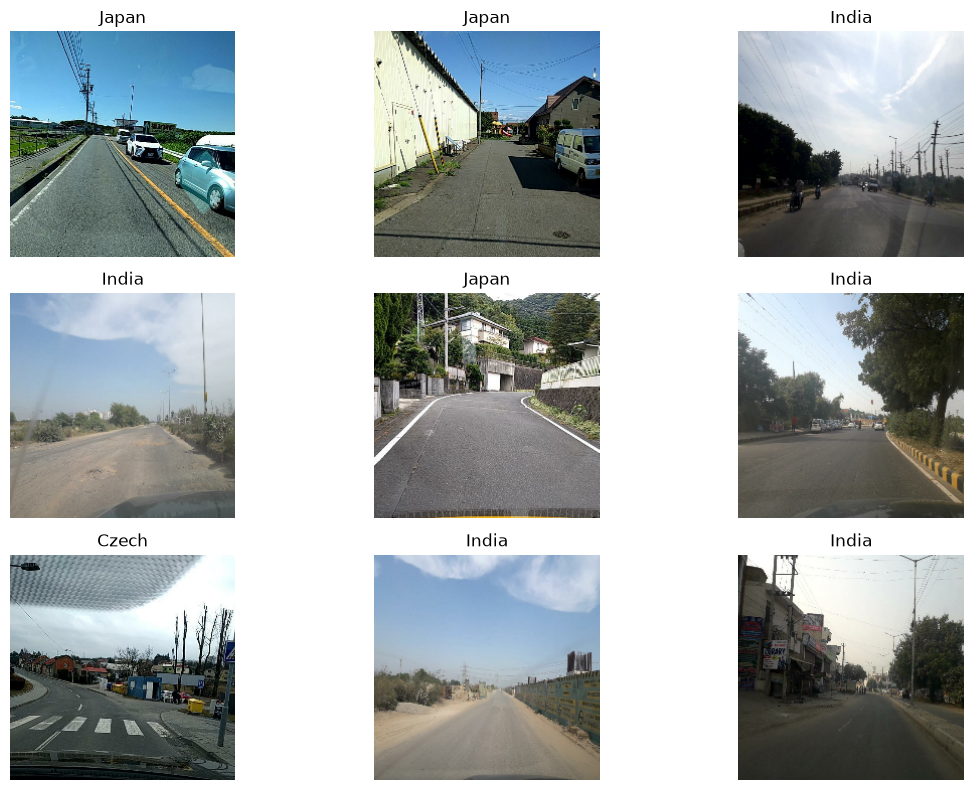

In [7]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")


In [9]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(1.0 / 255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Road-damage classification output
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,523 (19.48 MB)

 Trainable params: 5,107,523 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Custom CNN compiled successfully.")


Custom CNN compiled successfully.


In [11]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Callbacks ready.")


Callbacks ready.


In [12]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/10


c:\Users\dhana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


329/329 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.9083 - loss: 0.2582 - val_accuracy: 0.9753 - val_loss: 0.0733 - learning_rate: 0.0010
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 0.9743 - loss: 0.0828 - val_accuracy: 0.9871 - val_loss: 0.0423 - learning_rate: 0.0010
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.9818 - loss: 0.0653 - val_accuracy: 0.9932 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.9845 - loss: 0.0457 - val_accuracy: 0.9932 - val_loss: 0.0180 - learning_rate: 0.0010
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 348s 1s/step - accuracy: 0.9873 - loss: 0.0392 - val_accuracy: 0.9855 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9887 - loss: 0.0362
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
329/329 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.9887 - loss: 0.0362 - val_ac

In [19]:
validation_loss, validation_accuracy = model.evaluate(
    validation_dataset,
    verbose=1
)

print("\nCustom CNN Road Damage Validation Results")
print("=" * 55)
print(f"Validation Loss     : {validation_loss:.4f}")
print(f"Validation Accuracy : {validation_accuracy:.4f}")


83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - accuracy: 0.9989 - loss: 0.0044

Custom CNN Road Damage Validation Results
Validation Loss     : 0.0044
Validation Accuracy : 0.9989


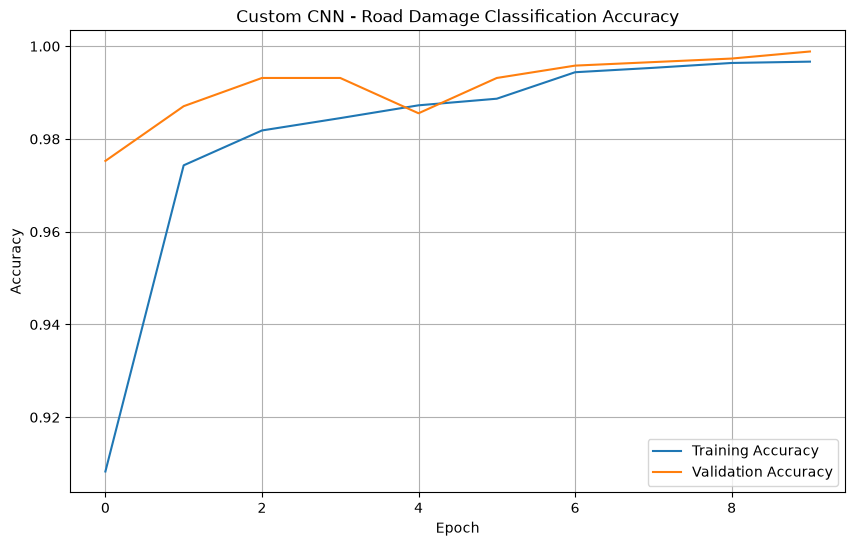

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Custom CNN - Road Damage Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


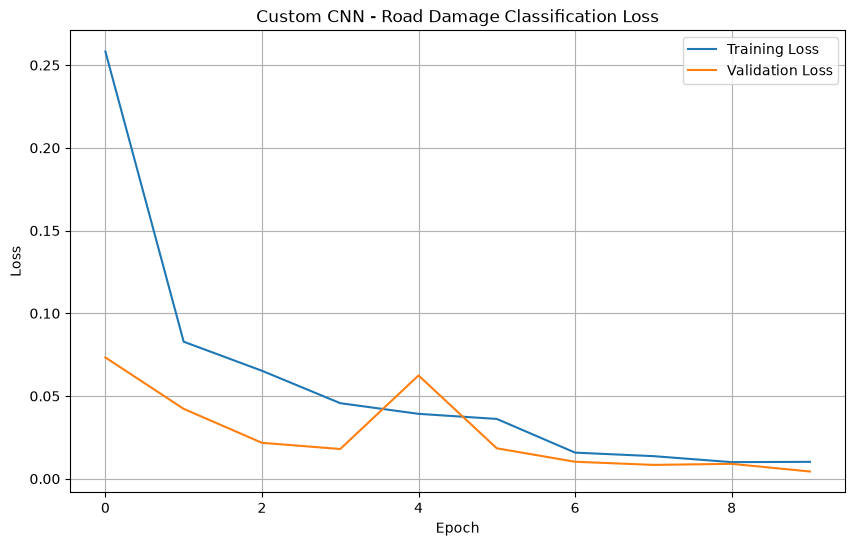

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Custom CNN - Road Damage Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


In [22]:
best_val_accuracy = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])

print("Final Custom CNN Road Damage Results")
print("=" * 55)
print(f"Best Validation Accuracy : {best_val_accuracy:.4f}")
print(f"Best Validation Loss     : {best_val_loss:.4f}")
print(f"Final Training Accuracy  : {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss      : {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss    : {history.history['val_loss'][-1]:.4f}")


Final Custom CNN Road Damage Results
Best Validation Accuracy : 0.9989
Best Validation Loss     : 0.0044
Final Training Accuracy  : 0.9967
Final Validation Accuracy: 0.9989
Final Training Loss      : 0.0102
Final Validation Loss    : 0.0044


In [23]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

model_path = RESULTS_DIR / "custom_cnn_road_damage.keras"
model.save(model_path)

print("Trained road-damage CNN saved successfully:")
print(model_path)


Trained road-damage CNN saved successfully:
results\custom_cnn_road_damage.keras


In [27]:
from tensorflow.keras.utils import load_img, img_to_array

# CHANGE THIS PATH to your test road image
IMAGE_PATH = "/content/my_road.jpg"

if not Path(IMAGE_PATH).is_file():
    print(f"Test image not found: {IMAGE_PATH}")
    print("Set IMAGE_PATH to the location of a road image and run this cell again.")
else:
    image = load_img(IMAGE_PATH, target_size=IMG_SIZE)
    image_array = img_to_array(image)
    image_batch = tf.expand_dims(image_array, 0)

    predictions = model.predict(image_batch, verbose=0)
    predicted_index = int(np.argmax(predictions[0]))
    predicted_class = CLASS_NAMES[predicted_index]
    confidence = float(predictions[0][predicted_index])

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}")
    plt.axis("off")
    plt.show()

    print("Predicted Road Damage Class:", predicted_class)
    print("Confidence:", f"{confidence:.2%}")


Test image not found: /content/my_road.jpg
Set IMAGE_PATH to the location of a road image and run this cell again.
